<a href="https://colab.research.google.com/github/Chirumamilla-TejaSri/Algo-Trading/blob/main/LSTM_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf

In [7]:
START = "2010-01-01"
TODAY = date.today().strftime("%Y-%m-%d")

# Define a function to load the dataset

def load_data(ticker):
    data = yf.download(ticker, START, TODAY)
    data.reset_index(inplace=True)
    return data

In [8]:
data = load_data('TCS.NS')
df=data
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2010-01-04,286.526886,289.290566,285.535759,287.727643,1963682
1,2010-01-05,286.603088,289.538311,284.582748,287.803869,2014488
2,2010-01-06,280.122650,286.736433,279.417445,286.603000,3349176
3,2010-01-07,272.327209,281.857137,271.031130,280.370459,6474892
4,2010-01-08,266.761780,273.890172,265.503834,272.937179,6048178


In [9]:
df = df.drop(['Date',], axis = 1)
df.head()

<ipython-input-9-dc3376343525>:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date',], axis = 1)


Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,286.526886,289.290566,285.535759,287.727643,1963682
1,286.603088,289.538311,284.582748,287.803869,2014488
2,280.122650,286.736433,279.417445,286.603000,3349176
3,272.327209,281.857137,271.031130,280.370459,6474892
4,266.761780,273.890172,265.503834,272.937179,6048178


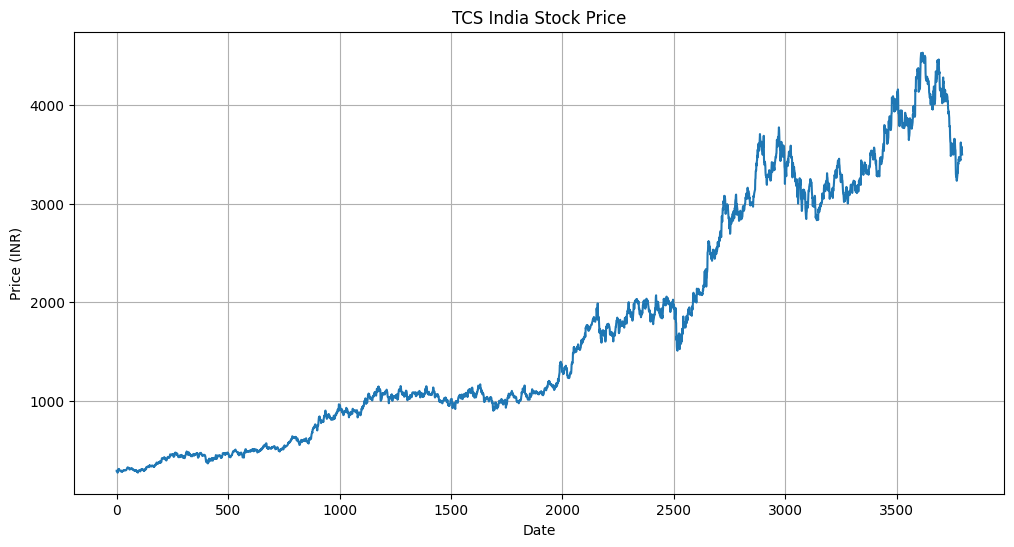

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title("TCS India Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.grid(True)
plt.show()

In [11]:
df

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,286.526886,289.290566,285.535759,287.727643,1963682
1,286.603088,289.538311,284.582748,287.803869,2014488
2,280.122650,286.736433,279.417445,286.603000,3349176
3,272.327209,281.857137,271.031130,280.370459,6474892
4,266.761780,273.890172,265.503834,272.937179,6048178
...,...,...,...,...,...
3789,3548.699951,3561.000000,3508.600098,3521.000000,2119499
3790,3579.899902,3600.000000,3514.100098,3564.000000,3548330
3791,3561.300049,3593.899902,3546.100098,3593.899902,1666727


In [12]:
ma100 = df.Close.rolling(100).mean()
ma100

Ticker,TCS.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3789,3776.916526
3790,3769.533430
3791,3761.771294
3792,3754.341853


Text(0.5, 1.0, 'Graph Of Moving Averages Of 100 Days')

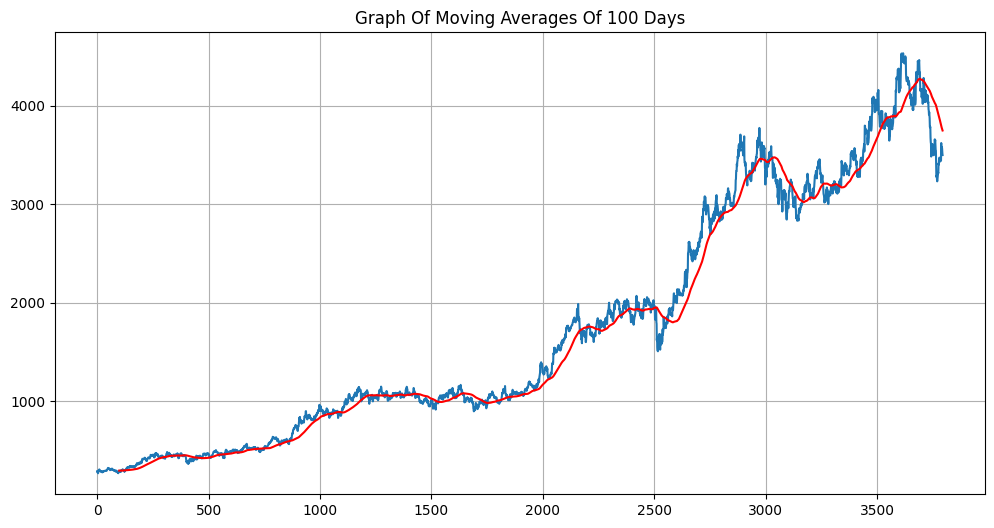

In [13]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.grid(True)
plt.title('Graph Of Moving Averages Of 100 Days')

In [14]:
ma200 = df.Close.rolling(200).mean()
ma200

Ticker,TCS.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3789,4024.952643
3790,4021.424357
3791,4017.722212
3792,4013.482386


Text(0.5, 1.0, 'Comparision Of 100 Days And 200 Days Moving Averages')

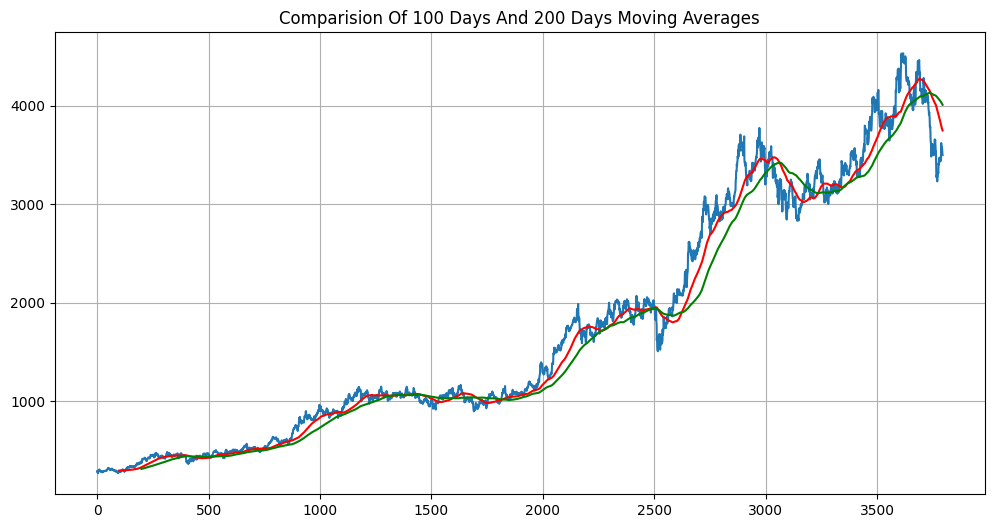

In [15]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')
plt.grid(True)
plt.title('Comparision Of 100 Days And 200 Days Moving Averages')

In [16]:
df.shape

(3794, 5)

In [17]:
# Splitting data into training and testing

train = pd.DataFrame(data[0:int(len(data)*0.70)])
test = pd.DataFrame(data[int(len(data)*0.70): int(len(data))])

print(train.shape)
print(test.shape)

(2655, 6)
(1139, 6)


In [18]:
train.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2010-01-04,286.526886,289.290566,285.535759,287.727643,1963682
1,2010-01-05,286.603088,289.538311,284.582748,287.803869,2014488
2,2010-01-06,280.122650,286.736433,279.417445,286.603000,3349176
3,2010-01-07,272.327209,281.857137,271.031130,280.370459,6474892
4,2010-01-08,266.761780,273.890172,265.503834,272.937179,6048178


In [19]:
test.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
2655,2020-10-09,2601.477051,2617.106672,2571.004222,2598.748872,7739245
2656,2020-10-12,2617.244385,2639.440097,2590.193361,2603.834475,4623203
2657,2020-10-13,2614.053467,2640.272013,2600.782192,2631.116373,4209878
2658,2020-10-14,2609.456787,2639.548666,2588.977485,2639.548666,4395936
2659,2020-10-15,2545.371826,2626.313554,2532.740540,2610.756750,6629355


In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [21]:
train_close = train.iloc[:, 4:5].values
test_close = test.iloc[:, 4:5].values

In [22]:
data_training_array = scaler.fit_transform(train_close)
data_training_array

array([[0.00834279],
       [0.00837563],
       [0.00785827],
       ...,
       [0.97449982],
       [0.97689061],
       [1.        ]])

In [23]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [24]:
x_train.shape

(2555, 100, 1)

In [25]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [26]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences=True
              ,input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))


model.add(LSTM(units = 60, activation = 'relu', return_sequences=True))
model.add(Dropout(0.3))


model.add(LSTM(units = 80, activation = 'relu', return_sequences=True))
model.add(Dropout(0.4))


model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
import tensorflow as tf
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics=[tf.keras.metrics.MeanAbsoluteError()])
model.fit(x_train, y_train,epochs = 100)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 282ms/step - loss: 0.0440 - mean_absolute_error: 0.1415
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 282ms/step - loss: 0.0051 - mean_absolute_error: 0.0485
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 280ms/step - loss: 0.0047 - mean_absolute_error: 0.0465
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 266ms/step - loss: 0.0044 - mean_absolute_error: 0.0461
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 276ms/step - loss: 0.0043 - mean_absolute_error: 0.0442
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 259ms/step - loss: 0.0039 - mean_absolute_error: 0.0428
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 43s 282ms/step - loss: 0.0035 - mean_absolute_error: 0.0404
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 280ms/step - loss: 0.0032 - mean_absolute_error: 0.0390
Epoch 9/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 279ms/step - loss: 0.0032 - mean_absolute_error: 0.0386
Epoch 10/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 280ms/step - loss: 0.0032 - mean_absolute_error: 0.0388
Epoch 11/

In [51]:
model.save('keras_model.h5')

In [30]:
test_close.shape

(1139, 1)

In [31]:
past_100_days = pd.DataFrame(train_close[-100:])

In [32]:
test_df = pd.DataFrame(test_close)

In [34]:
final_df = pd.concat([past_100_days, test_df], ignore_index=True)

In [35]:
final_df.head()

,0
0,1794.091906
1,1790.411479
2,1819.025221
3,1853.894626
4,1802.372234


In [36]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.00133175],
       [0.        ],
       [0.0103538 ],
       ...,
       [0.65258678],
       [0.63670174],
       [0.63011614]])

In [37]:
input_data.shape

(1239, 1)

In [38]:
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
   x_test.append(input_data[i-100: i])
   y_test.append(input_data[i, 0])

In [39]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(1139, 100, 1)
(1139,)


In [40]:
# Making predictions

y_pred = model.predict(x_test)

36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step


In [41]:
y_pred.shape

(1139, 1)

In [42]:
y_test

array([0.29249442, 0.29433463, 0.3042065 , ..., 0.65258678, 0.63670174,
       0.63011614])

In [43]:
y_pred

array([[0.22418234],
       [0.228986  ],
       [0.23388374],
       ...,
       [0.59928405],
       [0.6086587 ],
       [0.61451983]], dtype=float32)

In [44]:
scaler.scale_

array([0.00036185])

In [45]:
scale_factor = 1/0.00041967
y_pred = y_pred * scale_factor
y_test = y_test * scale_factor

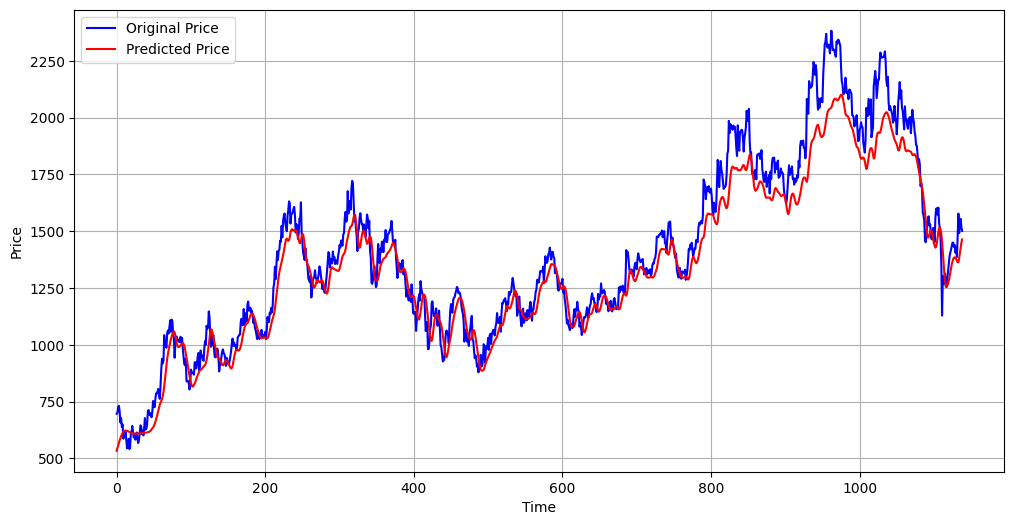

In [46]:
plt.figure(figsize = (12,6))
plt.plot(y_test, 'b', label = "Original Price")
plt.plot(y_pred, 'r', label = "Predicted Price")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mae_percentage = (mae / np.mean(y_test)) * 100
print("Mean absolute error on test set: {:.2f}%".format(mae_percentage))

Mean absolute error on test set: 5.78%


In [48]:
from sklearn.metrics import r2_score

# Actual values
actual = y_test

# Predicted values
predicted = y_pred

# Calculate the R2 score
r2 = r2_score(actual, predicted)

print("R2 score:", r2)

R2 score: 0.9290854467106446


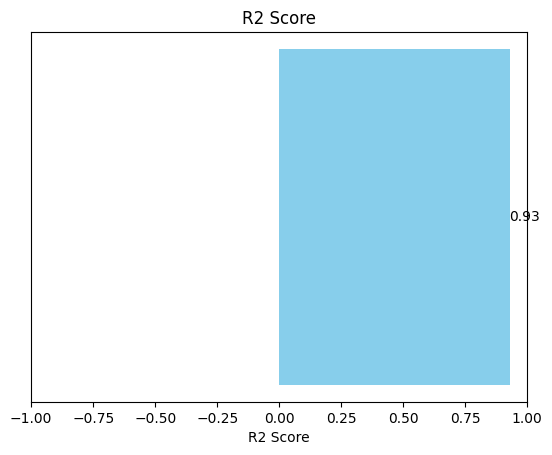

In [49]:
# Plotting the R2 score
fig, ax = plt.subplots()
ax.barh(0, r2, color='skyblue')
ax.set_xlim([-1, 1])
ax.set_yticks([])
ax.set_xlabel('R2 Score')
ax.set_title('R2 Score')

# Adding the R2 score value on the bar
ax.text(r2, 0, f'{r2:.2f}', va='center', color='black')

plt.show()

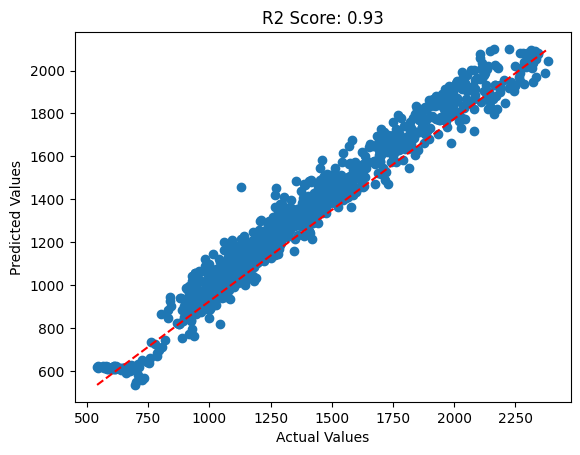

In [50]:
plt.scatter(actual, predicted)
plt.plot([min(actual), max(actual)], [min(predicted), max(predicted)], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'R2 Score: {r2:.2f}')
plt.show()